# MATH GR5360 Final Project — Notebook 03

Segmented trend-following performance notebook. This notebook consumes the TF walk-forward outputs, computes ledger-based performance metrics, measures the Chekhlov drawdown family, and runs the extended `T`/`tau` surface for the trend-following strategy.


In [1]:
MARKET_SELECT = 'TY'
QUICK_TEST = True
WALKFORWARD_MODE = 'tf'
RUN_EXTENDED_SURFACE = False

DATA_INTERVAL_MINUTES = 1
DATA_FILE_OVERRIDE = None  # use repo data folder
RESULTS_CACHE_DIR = r'/Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/results_py_corrected'
# Note: the repo currently contains TY-1minHLV.csv but no valid BTC-1minHLV.csv.


In [2]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD if (CWD / 'mafn_engine').exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from mafn_engine import (
    COLUMBIA_CORE,
    COLUMBIA_DIVERGING,
    COLUMBIA_NAVY,
    COLUMBIA_RED,
    apply_columbia_theme,
    choose_tf_story_configuration,
    default_tf_grid,
    drawdown_family,
    get_market,
    load_ohlc,
    performance_from_ledger,
    prepare_analysis_frame,
    run_backtest,
    walk_forward,
    walk_forward_surface,
)

apply_columbia_theme()
MARKET = get_market(MARKET_SELECT)
DATA_PATH = DATA_FILE_OVERRIDE or str(PROJECT_ROOT / 'data')
print(f"Market: {MARKET.ticker} - {MARKET.name} ({MARKET.exchange})")
print(f"PV=${MARKET.PV:,}  Slippage=${MARKET.slpg}  E0=${MARKET.E0:,.0f}")


Market: TY - 10-Year Treasury (CBOT-CME)
PV=$1,000  Slippage=$18.625  E0=$100,000


In [3]:
DEFAULT_T_VALUES = [1, 2, 3, 4, 5, 6]
DEFAULT_TAU_VALUES = [1, 2, 3, 4]


def _grid_signature(grid: dict[str, np.ndarray]) -> tuple[tuple[str, tuple[float, ...]], ...]:
    signature = []
    for key in sorted(grid):
        values = []
        for value in np.asarray(grid[key]).tolist():
            if isinstance(value, (int, np.integer)):
                values.append(int(value))
            else:
                values.append(float(value))
        signature.append((key, tuple(values)))
    return tuple(signature)


def _market_cache_dir() -> Path | None:
    if not RESULTS_CACHE_DIR:
        return None
    return Path(RESULTS_CACHE_DIR) / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m"


def _read_ledger_csv(path: Path) -> pd.DataFrame:
    ledger = pd.read_csv(path)
    for column in ['entry_time', 'exit_time']:
        if column in ledger.columns:
            ledger[column] = pd.to_datetime(ledger[column])
    return ledger


def ensure_analysis_state(force: bool = False) -> None:
    global MARKET, full_df, analysis_df, tf_grid, _analysis_signature

    MARKET = get_market(MARKET_SELECT)
    analysis_signature = (MARKET_SELECT, DATA_PATH, int(DATA_INTERVAL_MINUTES))
    if force or globals().get('_analysis_signature') != analysis_signature or 'analysis_df' not in globals():
        full_df = load_ohlc(DATA_PATH, MARKET_SELECT, fallback_synthetic=False, bar_minutes=DATA_INTERVAL_MINUTES)
        analysis_df = prepare_analysis_frame(full_df, MARKET_SELECT)
        _analysis_signature = analysis_signature

    tf_grid = default_tf_grid(MARKET_SELECT, quick=QUICK_TEST, bar_minutes=DATA_INTERVAL_MINUTES)


def ensure_walkforward_state(force: bool = False) -> None:
    global wf_bundle, wf_params, wf_equity, wf_ledger, wf_results, _wf_signature

    ensure_analysis_state(force=force)
    signature = (
        MARKET_SELECT,
        DATA_PATH,
        int(DATA_INTERVAL_MINUTES),
        WALKFORWARD_MODE,
        bool(QUICK_TEST),
        4,
        1,
        _grid_signature(tf_grid),
        str(_market_cache_dir()) if _market_cache_dir() else '',
    )

    if force or globals().get('_wf_signature') != signature or 'wf_bundle' not in globals():
        cache_dir = _market_cache_dir()
        params_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_params.csv" if cache_dir else None
        equity_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_equity.csv" if cache_dir else None
        ledger_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_walkforward_ledger.csv" if cache_dir else None

        if cache_dir and params_path.exists() and equity_path.exists() and ledger_path.exists():
            wf_params = pd.read_csv(params_path)
            wf_equity = pd.read_csv(equity_path, parse_dates=['DateTime']).set_index('DateTime')
            wf_ledger = _read_ledger_csv(ledger_path)
            wf_bundle = {'params': wf_params, 'equity': wf_equity, 'ledger': wf_ledger}
        else:
            wf_bundle = walk_forward(
                analysis_df,
                MARKET_SELECT,
                mode=WALKFORWARD_MODE,
                tf_grid=tf_grid,
                T_years=4,
                tau_quarters=1,
                quick=QUICK_TEST,
                verbose=False,
            )
            wf_params = wf_bundle['params']
            wf_equity = wf_bundle['equity']
            wf_ledger = wf_bundle['ledger']

        _wf_signature = signature

    wf_params = wf_bundle['params']
    wf_equity = wf_bundle['equity']
    wf_ledger = wf_bundle['ledger']
    wf_results = wf_params


def _fallback_modal_config() -> dict[str, object]:
    return choose_tf_story_configuration(MARKET_SELECT, tf_grid=tf_grid, params_df=wf_params)


def ensure_full_sample_state(force: bool = False) -> None:
    global modal_cfg, full_sample_result, full_sample_metrics, full_sample_metrics_df
    global _full_sample_signature

    ensure_walkforward_state(force=force)
    candidate = _fallback_modal_config()

    signature = (MARKET_SELECT, DATA_PATH, int(DATA_INTERVAL_MINUTES), tuple(sorted(candidate.items())), str(_market_cache_dir()) if _market_cache_dir() else '')
    if force or globals().get('_full_sample_signature') != signature or 'full_sample_result' not in globals():
        modal_cfg = dict(candidate)
        cache_dir = _market_cache_dir()
        equity_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_fullsample_equity.csv" if cache_dir else None
        ledger_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_fullsample_ledger.csv" if cache_dir else None
        metrics_path = cache_dir / f"{MARKET_SELECT}_{int(DATA_INTERVAL_MINUTES)}m_fullsample_metrics.csv" if cache_dir else None

        if cache_dir and equity_path.exists() and ledger_path.exists():
            equity_df = pd.read_csv(equity_path, parse_dates=['DateTime'])
            ledger_df = _read_ledger_csv(ledger_path)
            full_sample_result = {
                'Ledger': ledger_df,
                'Equity': equity_df['Equity'].to_numpy(dtype=float),
            }
            if metrics_path.exists():
                full_sample_metrics_df = pd.read_csv(metrics_path)
                full_sample_metrics = full_sample_metrics_df.iloc[0].to_dict()
            else:
                full_sample_metrics = performance_from_ledger(
                    full_sample_result['Ledger'],
                    full_sample_result['Equity'],
                    MARKET_SELECT,
                    bar_minutes=DATA_INTERVAL_MINUTES,
                )
                full_sample_metrics_df = pd.DataFrame([full_sample_metrics])
        else:
            full_sample_result = run_backtest(
                analysis_df,
                MARKET_SELECT,
                modal_cfg['family'],
                {k: v for k, v in modal_cfg.items() if k != 'family'},
            )
            full_sample_metrics = performance_from_ledger(
                full_sample_result['Ledger'],
                full_sample_result['Equity'],
                MARKET_SELECT,
                bar_minutes=DATA_INTERVAL_MINUTES,
            )
            full_sample_metrics_df = pd.DataFrame([full_sample_metrics])
        _full_sample_signature = signature


def ensure_surface_state(force: bool = False) -> None:
    global T_VALUES, TAU_VALUES, surface_df, surface_valid, _surface_signature

    ensure_walkforward_state(force=force)
    T_VALUES = globals().get('T_VALUES', DEFAULT_T_VALUES)
    TAU_VALUES = globals().get('TAU_VALUES', DEFAULT_TAU_VALUES)
    signature = (
        MARKET_SELECT,
        DATA_PATH,
        int(DATA_INTERVAL_MINUTES),
        WALKFORWARD_MODE,
        bool(QUICK_TEST),
        tuple(T_VALUES),
        tuple(TAU_VALUES),
        _grid_signature(tf_grid),
    )

    if force or globals().get('_surface_signature') != signature or 'surface_df' not in globals():
        surface_df = walk_forward_surface(
            analysis_df,
            MARKET_SELECT,
            mode=WALKFORWARD_MODE,
            tf_grid=tf_grid,
            T_values=T_VALUES,
            tau_values=TAU_VALUES,
            quick=QUICK_TEST,
            verbose=False,
        )
        surface_valid = surface_df[~surface_df['error']].copy() if len(surface_df) else surface_df
        _surface_signature = signature


ensure_analysis_state(force=True)
print('Setup complete. The cells below rebuild TF walk-forward, full-sample TF, and surface state as needed.')
if RESULTS_CACHE_DIR:
    print(f"Using cached strategy artifacts from {RESULTS_CACHE_DIR}")


✓ Loaded TY from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/data/TY-1minHLV.csv


Setup complete. The cells below rebuild TF walk-forward, full-sample TF, and surface state as needed.
Using cached strategy artifacts from /Users/nigelli/Desktop/Columbia MAFN/26Spring/MATH5360/Final Project/MATH5360_Final_Project/results_py_corrected


In [4]:
ensure_walkforward_state()

if len(wf_equity):
    oos_metrics = performance_from_ledger(wf_ledger, wf_equity['OOS_Equity'].values, MARKET_SELECT, bar_minutes=DATA_INTERVAL_MINUTES)
else:
    oos_metrics = performance_from_ledger(pd.DataFrame(), np.array([MARKET.E0]), MARKET_SELECT, bar_minutes=DATA_INTERVAL_MINUTES)

oos_metrics_df = pd.DataFrame([oos_metrics])
print('OOS PERFORMANCE METRICS')
print('-' * 72)
oos_metrics_df

OOS PERFORMANCE METRICS
------------------------------------------------------------------------


,Total Profit,Return %,Ann. Return %,Ann. Volatility %,Sharpe Ratio,Max Drawdown $,Max Drawdown %,Avg Drawdown $,CDD (α=0.05) $,DD Duration (bars),...,Total Trades,Win Rate %,Avg Winner $,Avg Loser $,Win/Loss Ratio,Profit Factor,Gross Profit $,Gross Loss $,Avg Trade PnL $,Avg Duration (bars)
0,71952.359375,71.952359,1.528776,5.110449,0.299147,15603.09375,9.949069,5647.168874,13085.195045,897389,...,401,32.917706,1269.158499,-883.2579,1.436906,0.705099,167528.921875,237596.375,-174.731803,4785.922693


In [5]:
ensure_full_sample_state()

print('FULL-SAMPLE TF CONFIGURATION')
print('-' * 72)
print(modal_cfg)
full_sample_metrics_df


FULL-SAMPLE TF CONFIGURATION
------------------------------------------------------------------------
{'family': 'tf', 'L': 6400, 'S': 0.01}


,Total Profit,Return %,Ann. Return %,Ann. Volatility %,Sharpe Ratio,Max Drawdown $,Max Drawdown %,Avg Drawdown $,CDD (α=0.05) $,DD Duration (bars),...,Total Trades,Win Rate %,Avg Winner $,Avg Loser $,Win/Loss Ratio,Profit Factor,Gross Profit $,Gross Loss $,Avg Trade PnL $,Avg Duration (bars)
0,97670.5625,97.670562,1.676079,4.158619,0.403037,13827.5,8.150265,4485.947484,11983.390108,1107193,...,772,41.450777,1168.929687,-611.475525,1.911654,1.353383,374057.5,276386.9375,126.516273,3190.931347


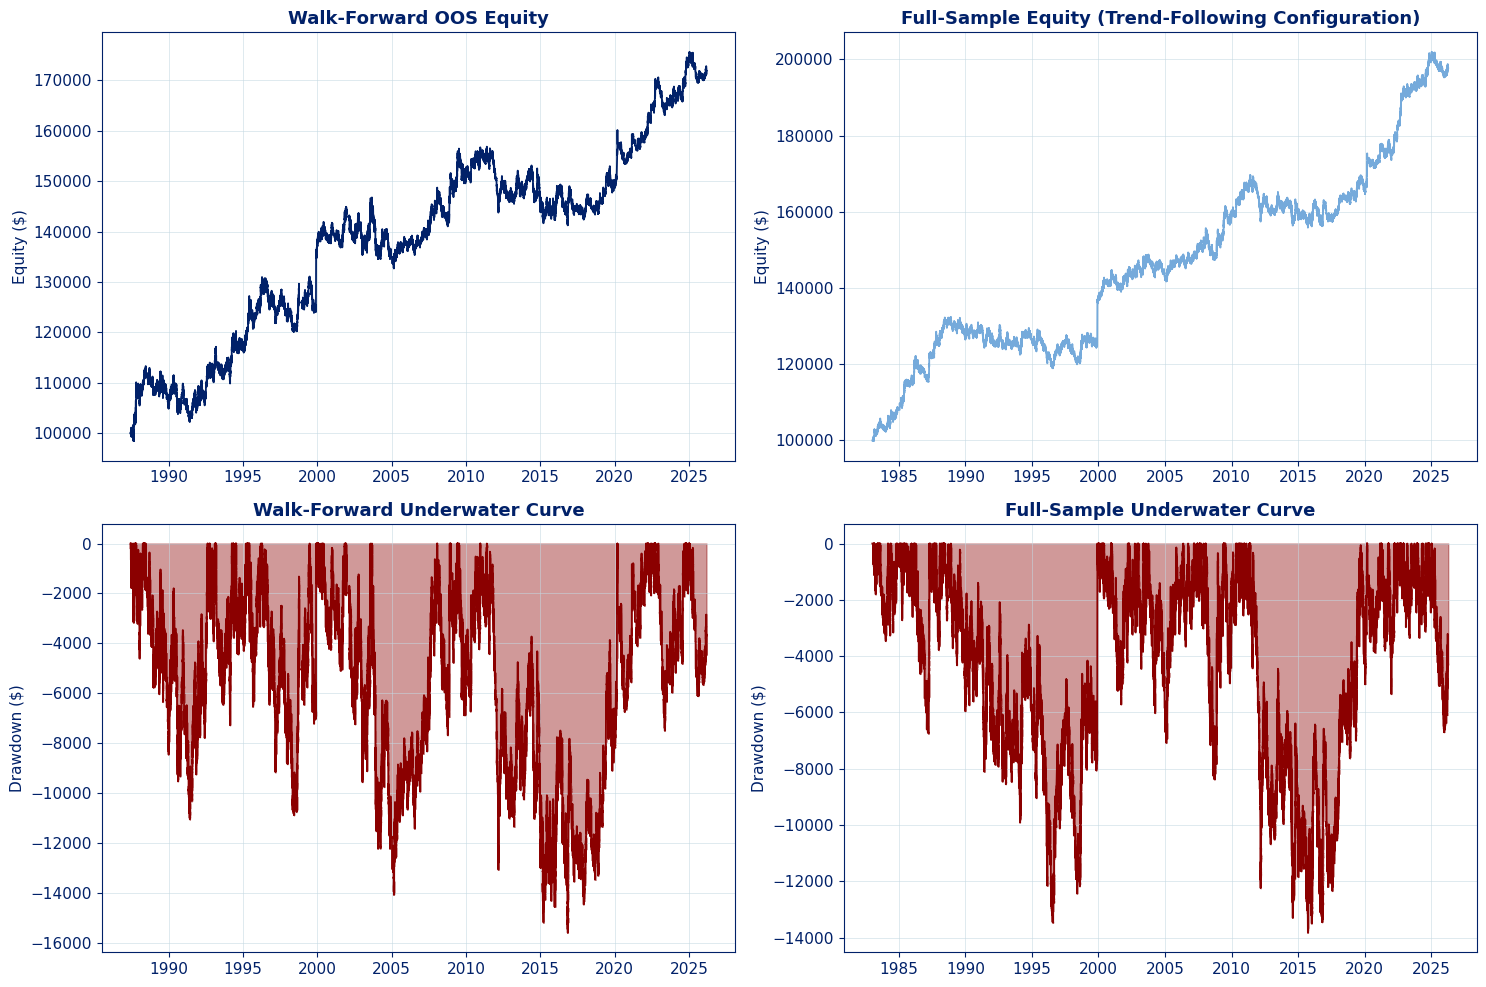

In [6]:
ensure_full_sample_state()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

if len(wf_equity):
    axes[0, 0].plot(wf_equity.index, wf_equity['OOS_Equity'], color=COLUMBIA_NAVY)
    axes[0, 0].set_title('Walk-Forward OOS Equity')
    axes[0, 0].set_ylabel('Equity ($)')

    oos_dd = drawdown_family(wf_equity['OOS_Equity'].values)
    axes[1, 0].fill_between(wf_equity.index, oos_dd['Underwater'], 0.0, color=COLUMBIA_RED, alpha=0.4)
    axes[1, 0].plot(wf_equity.index, oos_dd['Underwater'], color=COLUMBIA_RED)
    axes[1, 0].set_title('Walk-Forward Underwater Curve')
    axes[1, 0].set_ylabel('Drawdown ($)')
else:
    axes[0, 0].text(0.5, 0.5, 'No OOS equity generated', ha='center', va='center')
    axes[1, 0].text(0.5, 0.5, 'No OOS drawdown generated', ha='center', va='center')
    axes[0, 0].set_axis_off()
    axes[1, 0].set_axis_off()

axes[0, 1].plot(analysis_df.index, full_sample_result['Equity'], color=COLUMBIA_CORE)
axes[0, 1].set_title('Full-Sample Equity (Trend-Following Configuration)')
axes[0, 1].set_ylabel('Equity ($)')

full_dd = drawdown_family(full_sample_result['Equity'])
axes[1, 1].fill_between(analysis_df.index, full_dd['Underwater'], 0.0, color=COLUMBIA_RED, alpha=0.4)
axes[1, 1].plot(analysis_df.index, full_dd['Underwater'], color=COLUMBIA_RED)
axes[1, 1].set_title('Full-Sample Underwater Curve')
axes[1, 1].set_ylabel('Drawdown ($)')

plt.tight_layout()
plt.show()


In [7]:
if RUN_EXTENDED_SURFACE:
    T_VALUES = DEFAULT_T_VALUES
    TAU_VALUES = DEFAULT_TAU_VALUES
    ensure_surface_state(force=True)
    surface_valid
else:
    print('Extended T/tau surface skipped. Set RUN_EXTENDED_SURFACE = True to run the assignment sweep.')


Extended T/tau surface skipped. Set RUN_EXTENDED_SURFACE = True to run the assignment sweep.


In [8]:
if RUN_EXTENDED_SURFACE:
    ensure_surface_state()

    if len(surface_valid):
        decay_pivot = surface_valid.pivot(index='T', columns='tau', values='decay')
        oos_pivot = surface_valid.pivot(index='T', columns='tau', values='total_oos')

        fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
        im1 = axes[0].imshow(decay_pivot.values, cmap='Blues', aspect='auto', vmin=0)
        axes[0].set_xticks(range(len(decay_pivot.columns)))
        axes[0].set_xticklabels([f"{x}Q" for x in decay_pivot.columns])
        axes[0].set_yticks(range(len(decay_pivot.index)))
        axes[0].set_yticklabels([f"{x}Y" for x in decay_pivot.index])
        axes[0].set_title('OOS / IS Objective Decay')
        plt.colorbar(im1, ax=axes[0], label='decay')

        oos_values = oos_pivot.to_numpy(dtype=float)
        if np.all(np.isnan(oos_values)):
            vmax = 1.0
        else:
            vmax = max(abs(np.nanmin(oos_values)), abs(np.nanmax(oos_values)))
            vmax = max(vmax, 1e-9)

        im2 = axes[1].imshow(
            oos_values / 1000.0,
            cmap=COLUMBIA_DIVERGING,
            aspect='auto',
            vmin=-vmax / 1000.0,
            vmax=vmax / 1000.0,
        )
        axes[1].set_xticks(range(len(oos_pivot.columns)))
        axes[1].set_xticklabels([f"{x}Q" for x in oos_pivot.columns])
        axes[1].set_yticks(range(len(oos_pivot.index)))
        axes[1].set_yticklabels([f"{x}Y" for x in oos_pivot.index])
        axes[1].set_title('Total OOS Profit ($K)')
        plt.colorbar(im2, ax=axes[1], label='OOS Profit ($K)')

        plt.tight_layout()
        plt.show()

        best_surface = surface_valid.loc[surface_valid['decay'].idxmax()]
        print()
        print('BEST EXTENDED SETTING')
        print('-' * 72)
        print(best_surface)
    else:
        print('No valid extended-analysis combinations were produced.')
else:
    print('Extended T/tau surface skipped. Set RUN_EXTENDED_SURFACE = True to run the assignment sweep.')


Extended T/tau surface skipped. Set RUN_EXTENDED_SURFACE = True to run the assignment sweep.
